The four adjacent digits in the 1000-digit number that have the greatest product are 9x9x8x9=5832.

Find the thirteen adjacent digits in the 1000-digit number that have the greatest product. What is the value of this product?

In [2]:
number ='''
73167176531330624919225119674426574742355349194934
96983520312774506326239578318016984801869478851843
85861560789112949495459501737958331952853208805511
12540698747158523863050715693290963295227443043557
66896648950445244523161731856403098711121722383113
62229893423380308135336276614282806444486645238749
30358907296290491560440772390713810515859307960866
70172427121883998797908792274921901699720888093776
65727333001053367881220235421809751254540594752243
52584907711670556013604839586446706324415722155397
53697817977846174064955149290862569321978468622482
83972241375657056057490261407972968652414535100474
82166370484403199890008895243450658541227588666881
16427171479924442928230863465674813919123162824586
17866458359124566529476545682848912883142607690042
24219022671055626321111109370544217506941658960408
07198403850962455444362981230987879927244284909188
84580156166097919133875499200524063689912560717606
05886116467109405077541002256983155200055935729725
71636269561882670428252483600823257530420752963450
'''.replace('\n', '')
n=1_000

# Primer intento:

primer intento basado en slicer de strings de python

In [3]:
import math
def primer_intento():
    n_int = 0
    for i in range(n - 12):
        n_int = max(n_int, math.prod(map(lambda x: int(x), number[i:13+i:])))
    return n_int

primer_intento()

23514624000

# Optimizacion:

chatgpt recomienda usar una ventana deslizante para actualizar el producto en cada paso y tratar los ceros aparte, pero trabajando directamente sobre el string para no reservar una lista adicional de digitos:

In [4]:
def optimizacion():
    ancho = 13
    resultado = 0
    producto = 1
    ceros = 0
    izquierda = 0

    for derecha, caracter in enumerate(number):
        digito = ord(caracter) - 48
        if digito == 0:
            ceros += 1
        else:
            producto *= digito

        if derecha - izquierda + 1 > ancho:
            saliente = ord(number[izquierda]) - 48
            if saliente == 0:
                ceros -= 1
            else:
                producto //= saliente
            izquierda += 1

        if derecha - izquierda + 1 == ancho and ceros == 0:
            if producto > resultado:
                resultado = producto

    return resultado

optimizacion()

23514624000

# Comparacion:

Esta celda compara ambos metodos en tiempo y memoria.


--- Primer intento ---
Resultado: 23514624000
Consistente: True
Tiempo promedio: 0.003796 s
Tiempo minimo: 0.003433 s
Memoria promedio: 0.70 KB
Memoria maxima: 1.50 KB

--- Optimizacion ---
Resultado: 23514624000
Consistente: True
Tiempo promedio: 0.001004 s
Tiempo minimo: 0.000928 s
Memoria promedio: 0.46 KB
Memoria maxima: 1.06 KB


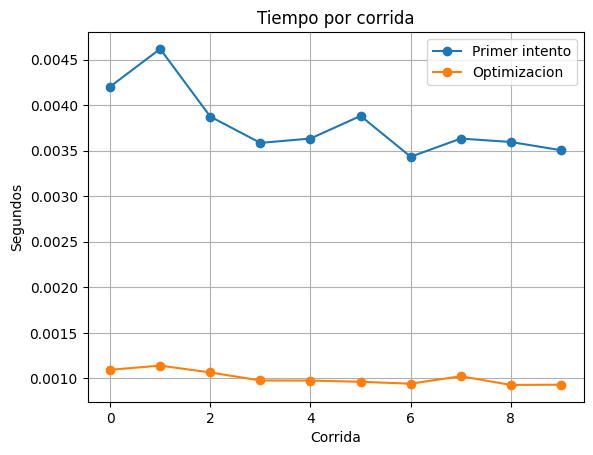

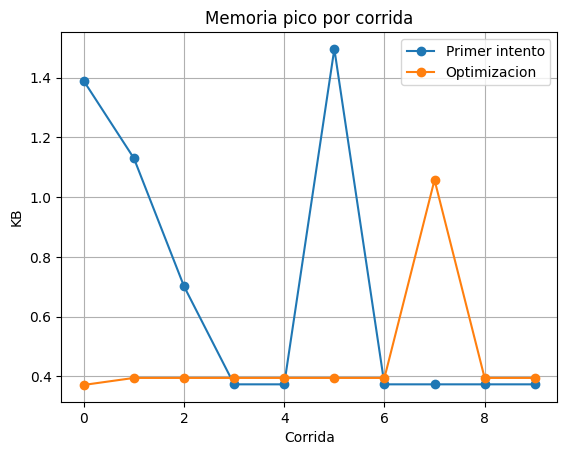

In [5]:
import time
import tracemalloc
import matplotlib.pyplot as plt


def medir(funcion, corridas=10):
    tiempos = []
    memorias = []
    resultados = []

    for _ in range(corridas):
        tracemalloc.start()

        tiempo_inicial = time.process_time()
        resultado = funcion()
        tiempo_final = time.process_time()

        _, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        tiempos.append(tiempo_final - tiempo_inicial)
        memorias.append(memoria_pico / 1024)
        resultados.append(resultado)

    return {
        "resultado": resultados[0] if len(set(resultados)) == 1 else None,
        "consistente": len(set(resultados)) == 1,
        "tiempos": tiempos,
        "memorias": memorias,
    }


metodos = {
    "Primer intento": primer_intento,
    "Optimizacion": optimizacion,
}

comparaciones = {
    nombre: medir(funcion, corridas=10)
    for nombre, funcion in metodos.items()
}

for nombre, datos in comparaciones.items():
    print(f"\n--- {nombre} ---")
    print("Resultado:", datos["resultado"])
    print("Consistente:", datos["consistente"])
    print(f"Tiempo promedio: {sum(datos['tiempos']) / len(datos['tiempos']):.6f} s")
    print(f"Tiempo minimo: {min(datos['tiempos']):.6f} s")
    print(f"Memoria promedio: {sum(datos['memorias']) / len(datos['memorias']):.2f} KB")
    print(f"Memoria maxima: {max(datos['memorias']):.2f} KB")


plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["tiempos"], marker="o", label=nombre)
plt.title("Tiempo por corrida")
plt.xlabel("Corrida")
plt.ylabel("Segundos")
plt.legend()
plt.grid()

plt.figure()
for nombre, datos in comparaciones.items():
    plt.plot(datos["memorias"], marker="o", label=nombre)
plt.title("Memoria pico por corrida")
plt.xlabel("Corrida")
plt.ylabel("KB")
plt.legend()
plt.grid()

plt.show()